<a href="https://colab.research.google.com/github/pejmanrasti/traitement_des_signaux_M1/blob/main/05_Convolution.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Understanding Convolution

Convolution is a mathematical operation on two functions that produces a third function expressing how the shape of one is modified by the other. It's a fundamental operation in signal processing, image processing, and many other fields. Intuitively, it can be thought of as a 'moving average' or a 'weighted sum' where one signal (the kernel) slides over another signal, multiplying and summing values at each position.

Mathematically, for discrete signals $x[n]$ and $h[n]$, the convolution $y[n]$ is defined as:

$y[n] = (x * h)[n] = \sum_{k=-\infty}^{\infty} x[k]h[n-k]$

Let's look at some examples.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Set a clean plot style
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = [10, 6]
plt.rcParams['lines.linewidth'] = 2
plt.rcParams['font.size'] = 12

### Example 1: Convolving a Square Pulse with a Rectangular Window

In this example, we'll convolve a simple square pulse (our input signal) with a rectangular window (our kernel). This operation can be thought of as smoothing or averaging the input signal.

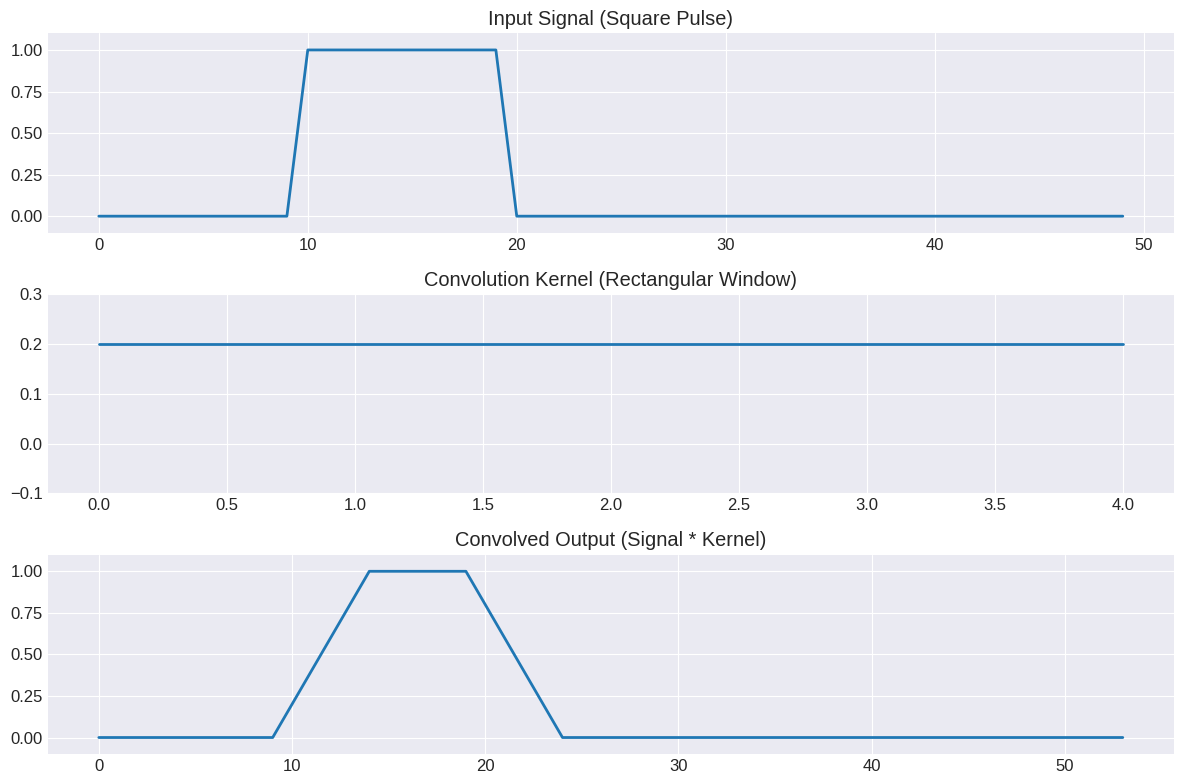

In [2]:
# Define the input signal (a square pulse)
signal = np.zeros(50)
signal[10:20] = 1.0 # A pulse from index 10 to 19

# Define the kernel (a rectangular window)
kernel = np.ones(5) / 5.0 # A 5-point moving average filter

# Perform convolution
convolved_signal_1 = np.convolve(signal, kernel, mode='full')

# Plot the signals
plt.figure(figsize=(12, 8))

plt.subplot(3, 1, 1)
plt.plot(signal)
plt.title('Input Signal (Square Pulse)')
plt.ylim(-0.1, 1.1)

plt.subplot(3, 1, 2)
plt.plot(kernel)
plt.title('Convolution Kernel (Rectangular Window)')
plt.ylim(-0.1, 0.3)

plt.subplot(3, 1, 3)
plt.plot(convolved_signal_1)
plt.title('Convolved Output (Signal * Kernel)')
plt.ylim(-0.1, 1.1)

plt.tight_layout()
plt.show()

### Explanation of Example 1:

As the rectangular window (kernel) slides over the square pulse (signal), it averages the values. This results in the output signal having a trapezoidal shape, with ramp-up and ramp-down sections. The width of these ramps is determined by the width of the kernel. This illustrates how convolution can be used for smoothing, where sharp changes in the input are softened in the output.

### Example 2: Convolving a Noisy Signal with a Gaussian Kernel

Here, we'll create a signal with some noise and then use a Gaussian kernel to smooth it. Gaussian kernels are widely used for blurring and noise reduction because of their smooth, bell-shaped response.

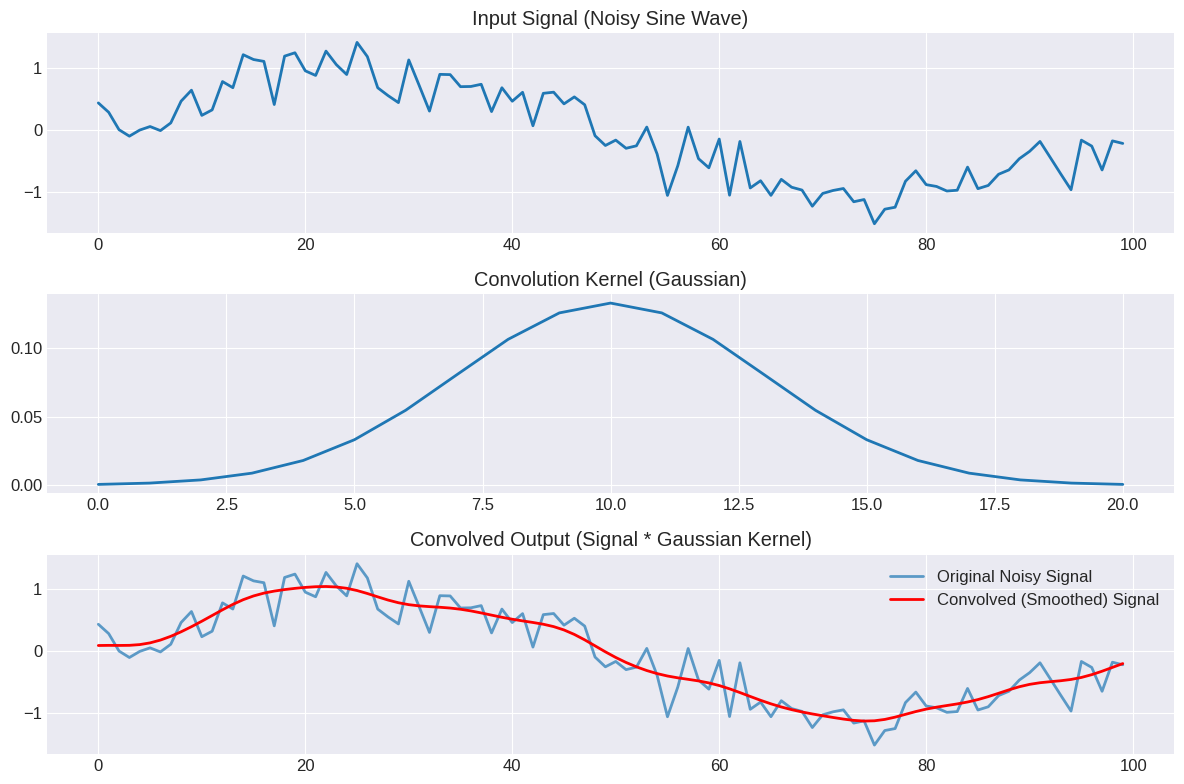

In [3]:
# Define an input signal (sine wave with noise)
samples = np.linspace(0, 2 * np.pi, 100)
signal_noisy = np.sin(samples) + np.random.normal(0, 0.3, 100)

# Define a Gaussian kernel
def gaussian_kernel(length, sigma):
    half_length = length // 2
    x = np.linspace(-half_length, half_length, length)
    kernel = np.exp(-x**2 / (2 * sigma**2))
    return kernel / np.sum(kernel) # Normalize the kernel

kernel_gaussian = gaussian_kernel(length=21, sigma=3)

# Perform convolution
convolved_signal_2 = np.convolve(signal_noisy, kernel_gaussian, mode='same') # 'same' mode returns output of same length as signal

# Plot the signals
plt.figure(figsize=(12, 8))

plt.subplot(3, 1, 1)
plt.plot(signal_noisy)
plt.title('Input Signal (Noisy Sine Wave)')

plt.subplot(3, 1, 2)
plt.plot(kernel_gaussian)
plt.title('Convolution Kernel (Gaussian)')

plt.subplot(3, 1, 3)
plt.plot(signal_noisy, label='Original Noisy Signal', alpha=0.7)
plt.plot(convolved_signal_2, label='Convolved (Smoothed) Signal', color='red')
plt.title('Convolved Output (Signal * Gaussian Kernel)')
plt.legend()

plt.tight_layout()
plt.show()

### Explanation of Example 2:

By convolving the noisy sine wave with a Gaussian kernel, the high-frequency noise components are attenuated, resulting in a much smoother output signal that more closely resembles the original, underlying sine wave. The Gaussian kernel effectively performs a weighted average, with values closer to the center of the kernel having a stronger influence on the output. This is a common technique for noise reduction in various applications.

### Example 3: Convolving an Audio Signal (Echo Effect)

Convolution is also fundamental in audio processing. A common application is adding effects like reverb or echo. Here, we'll create a simple echo by convolving a sound wave with a kernel that contains a delayed, attenuated impulse.

In [5]:
!pip install sounddevice soundfile

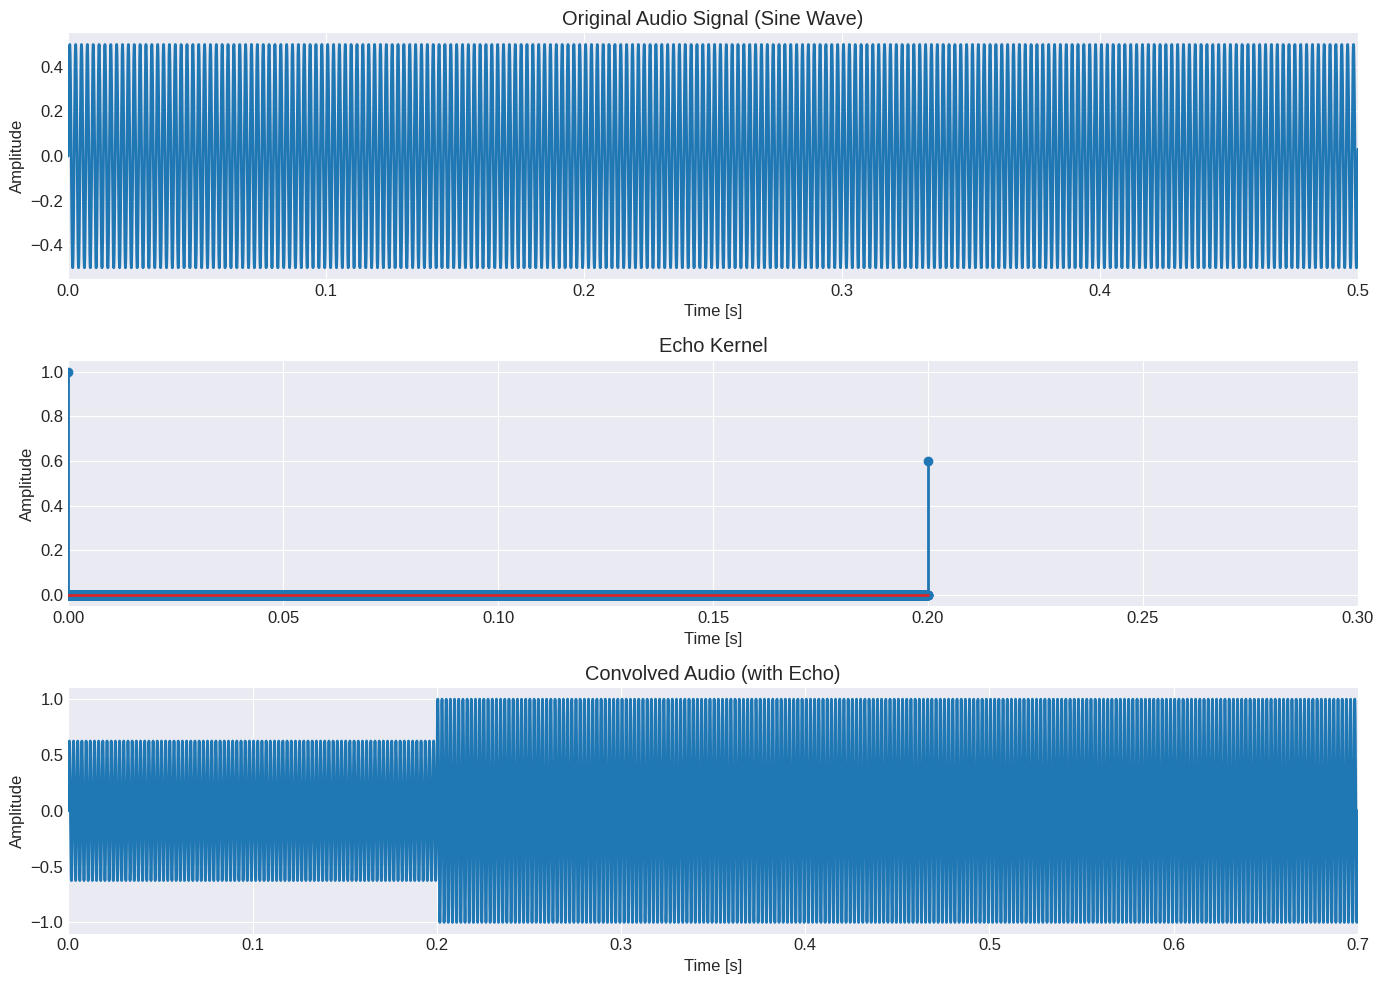

In [9]:
# import sounddevice as sd
import soundfile as sf
from scipy.io import wavfile

# Generate a simple sine wave as our 'audio signal'
# In a real scenario, you'd load a .wav file:
# samplerate, signal_audio = wavfile.read('your_audio_file.wav')

samplerate = 44100  # samples per second
duration = 1.0      # seconds
frequencysine = 440 # Hz

t = np.linspace(0., duration, int(samplerate * duration), endpoint=False)
signal_audio = 0.5 * np.sin(2 * np.pi * frequencysine * t)

# Define an echo kernel
echo_delay_samples = int(0.2 * samplerate) # 200 ms delay
echo_amplitude = 0.6 # 60% of original volume

kernel_echo = np.zeros(echo_delay_samples + 1)
kernel_echo[0] = 1.0 # Original sound
kernel_echo[echo_delay_samples] = echo_amplitude # Echo

# Perform convolution
convolved_audio = np.convolve(signal_audio, kernel_echo)

# Normalize the convolved audio to prevent clipping
convolved_audio = convolved_audio / np.max(np.abs(convolved_audio))

# Plot the signals
plt.figure(figsize=(14, 10))

plt.subplot(3, 1, 1)
plt.plot(t, signal_audio)
plt.title('Original Audio Signal (Sine Wave)')
plt.xlabel('Time [s]')
plt.ylabel('Amplitude')
plt.xlim(0, 0.5)

plt.subplot(3, 1, 2)
plt.stem(np.arange(len(kernel_echo)) / samplerate, kernel_echo)
plt.title('Echo Kernel')
plt.xlabel('Time [s]')
plt.ylabel('Amplitude')
plt.xlim(0, 0.3)

plt.subplot(3, 1, 3)
plt.plot(np.linspace(0, len(convolved_audio)/samplerate, len(convolved_audio)), convolved_audio)
plt.title('Convolved Audio (with Echo)')
plt.xlabel('Time [s]')
plt.ylabel('Amplitude')
plt.xlim(0, 0.7)

plt.tight_layout()
plt.show()

# Play the original and convolved audio (requires speakers/headphones)
# print('Playing original audio...')
# sd.play(signal_audio, samplerate)
# sd.wait()
# print('Playing convolved audio (with echo)...')
# sd.play(convolved_audio, samplerate)
# sd.wait()


### Explanation of Example 3:

By convolving the original sine wave with an echo kernel (which is essentially two impulses: one at time 0 and one delayed and attenuated), we create a distinct echo. The original sound is immediately followed by a fainter, delayed repetition. In a real-world scenario, you would load an actual audio file and apply more complex kernels for realistic reverb or other effects. Note that playing audio in Colab sometimes requires specific configurations or can be inconsistent depending on the environment.

### Example 4: Image Denoising with a Gaussian Kernel (2D Convolution)

Convolution is a cornerstone of image processing. Here, we'll demonstrate how a 2D Gaussian kernel can be used to denoise an image. A Gaussian filter blurs the image, effectively averaging pixel values and reducing random noise.

<>:48: SyntaxWarning: invalid escape sequence '\s'
<>:48: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipython-input-1715952443.py:48: SyntaxWarning: invalid escape sequence '\s'
  plt.title(f'Denoised Image (Gaussian, $\sigma$={sigma})')


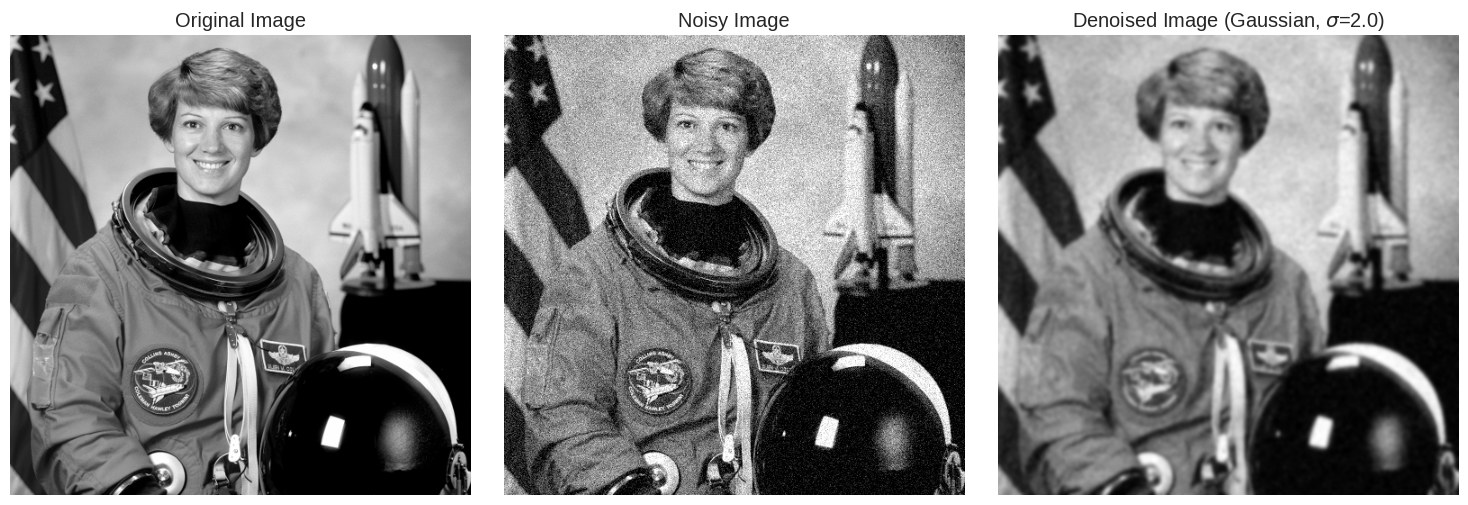

In [10]:
from PIL import Image
import scipy.ndimage as ndi
import skimage.data

# Load a sample image (e.g., grayscale astronaut image)
original_image_rgb = skimage.data.astronaut()
original_image = skimage.color.rgb2gray(original_image_rgb)

# Add Gaussian noise to the image
noisy_image = original_image + 0.1 * np.random.normal(0, 1, original_image.shape)
noisy_image = np.clip(noisy_image, 0, 1) # Clip values to be between 0 and 1

# Define a 2D Gaussian kernel
def gaussian_kernel_2d(sigma, size=None):
    if size is None:
        # Determine an appropriate kernel size based on sigma
        # A common rule of thumb is 6*sigma for kernel size
        size = int(6 * sigma) + 1
        if size % 2 == 0: size += 1 # Ensure odd size

    # Create 1D Gaussian kernels
    kernel_1d = np.linspace(-(size // 2), (size // 2), size)
    x, y = np.meshgrid(kernel_1d, kernel_1d)
    kernel_2d = np.exp(-(x**2 + y**2) / (2 * sigma**2))
    return kernel_2d / np.sum(kernel_2d) # Normalize the kernel

sigma = 2.0 # Standard deviation of the Gaussian
kernel_gaussian_2d = gaussian_kernel_2d(sigma)

# Perform 2D convolution for denoising
denoised_image = ndi.convolve(noisy_image, kernel_gaussian_2d, mode='nearest')

# Plot the images
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(original_image, cmap='gray')
plt.title('Original Image')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(noisy_image, cmap='gray')
plt.title('Noisy Image')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(denoised_image, cmap='gray')
plt.title(f'Denoised Image (Gaussian, $\sigma$={sigma})')
plt.axis('off')

plt.tight_layout()
plt.show()

### Explanation of Example 4:

In this example, we started with a grayscale image, added some random Gaussian noise to it, and then applied a 2D Gaussian kernel using convolution. The Gaussian kernel effectively blurs the image, which has the effect of averaging out the high-frequency noise components. You can observe that the denoised image is smoother than the noisy image, although some fine details might also be blurred along with the noise. The `sigma` parameter of the Gaussian kernel controls the degree of blurring: a larger `sigma` leads to more blurring and thus more noise reduction, but also more loss of detail.